In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from utils import neural_utils as nu

$-u_{xx} = f(x)$

$f(x) = (k\pi)^2\sin(k \pi x)$

$x \in [0,1]$

$u(0) = u(1) = 0$

solution: $u(x) = \sin(k \pi x)$

In [3]:
device = 'cpu'

seed = 0

np.random.seed(seed)
torch.manual_seed(seed)

X_data = torch.tensor([0.0,1.0]).unsqueeze(1).to(device)
U_data = torch.tensor([0.0,0.0]).unsqueeze(1).to(device)

N_col = 1000

X_col = torch.linspace(0, 1, N_col).unsqueeze(1).to(device)


In [4]:
def make_residual(k):
    def f(X, u, grad_U):
        u_xx = nu.gradients(grad_U, X)[:]
        return u_xx + (k * torch.pi)**2 * torch.sin(k * torch.pi * X)
    return f

f_1 = make_residual(1)

In [5]:
# loop over k need to add random fourier later
# use checkpointing callback in training loop
save_dir = r"C:\Users\victo\GitHub Projects\DiffEqML\demos\temp_saves"
os.makedirs(save_dir, exist_ok=True)

k_value = [1, 4, 16, 64]
losses = {
    "model_t": [],
    "model_s": []
}
checkpoint_data = {
    "model_t": [],
    "model_s": []
}
epochs = 40000
for k in k_value:
    f = make_residual(k)
    model_t = nu.FCN(1, 1, 50, 5).to(device)
    model_s = nu.FCN(1, 1, 50, 5, SIREN=True).to(device)

    optimizer_t = torch.optim.Adam(model_t.parameters(), lr=1e-4)
    optimizer_s = torch.optim.Adam(model_s.parameters(), lr=1e-4)

    callbacks_t = [nu.CheckpointCallback(), nu.LoggingCallback()]
    callbacks_s = [nu.CheckpointCallback(), nu.LoggingCallback()]

    loss_t, data_loss_t, physics_loss_t, results_t = nu.train(
        epochs, optimizer_t, X_data, U_data, model_t, f, 1.0, X_col, callbacks=callbacks_t
    )
    loss_s, data_loss_s, physics_loss_s, results_s = nu.train(
        epochs, optimizer_s, X_data, U_data, model_s, f, 1.0, X_col, callbacks=callbacks_s
    )

    losses["model_t"].append((loss_t, physics_loss_t, data_loss_t))
    losses["model_s"].append((loss_s, physics_loss_s, data_loss_s))

    checkpoint_data["model_t"].append({"k": k, "checkpoint": results_t["CheckpointCallback"]})
    checkpoint_data["model_s"].append({"k": k, "checkpoint": results_s["CheckpointCallback"]})

# save the full checkpoint_data dictionary to disk
checkpoint_path = os.path.join(save_dir, "spectral_bias_50_5_arch.pt")
torch.save(checkpoint_data, checkpoint_path)
print(f"Saved checkpoint data to {checkpoint_path}")

Epoch     0 | Total Loss: 4.7918e+01 | Data Loss: 2.4463e-03 | Physics Loss: 4.7915e+01
Epoch   100 | Total Loss: 2.9097e+01 | Data Loss: 6.5602e-01 | Physics Loss: 2.8441e+01
Epoch   200 | Total Loss: 8.0877e+00 | Data Loss: 3.0929e+00 | Physics Loss: 4.9948e+00
Epoch   300 | Total Loss: 6.6594e+00 | Data Loss: 3.0797e+00 | Physics Loss: 3.5797e+00
Epoch   400 | Total Loss: 7.5779e-01 | Data Loss: 4.0172e-01 | Physics Loss: 3.5607e-01
Epoch   500 | Total Loss: 2.1406e-02 | Data Loss: 9.6804e-03 | Physics Loss: 1.1726e-02
Epoch   600 | Total Loss: 1.0015e-02 | Data Loss: 3.6266e-03 | Physics Loss: 6.3880e-03
Epoch   700 | Total Loss: 5.2809e-03 | Data Loss: 1.1605e-03 | Physics Loss: 4.1205e-03
Epoch   800 | Total Loss: 3.5721e-03 | Data Loss: 3.0825e-04 | Physics Loss: 3.2638e-03
Epoch   900 | Total Loss: 3.0319e-03 | Data Loss: 6.4127e-05 | Physics Loss: 2.9678e-03
Epoch  1000 | Total Loss: 2.8730e-03 | Data Loss: 8.9357e-06 | Physics Loss: 2.8641e-03
Epoch  1100 | Total Loss: 2.8209

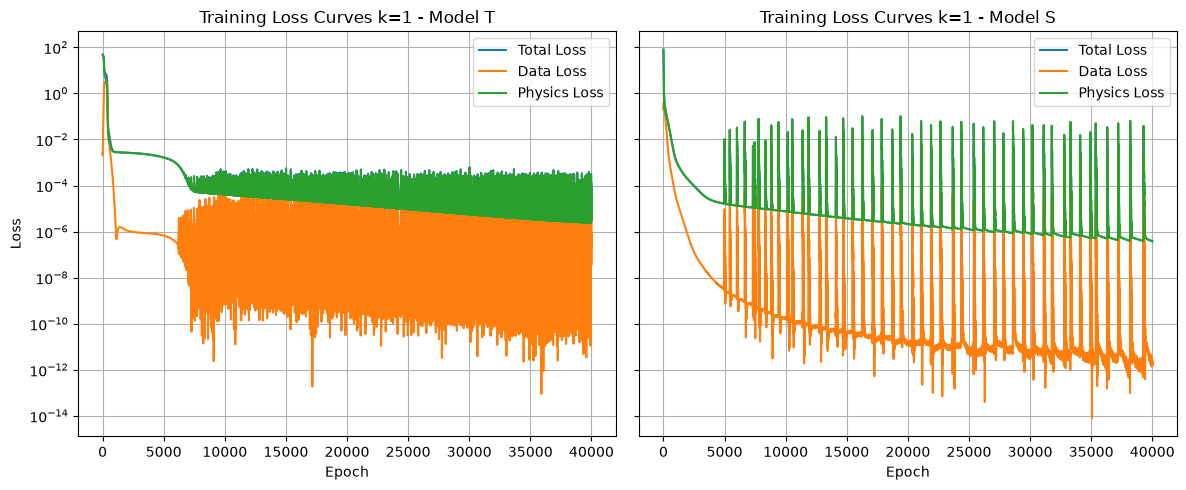

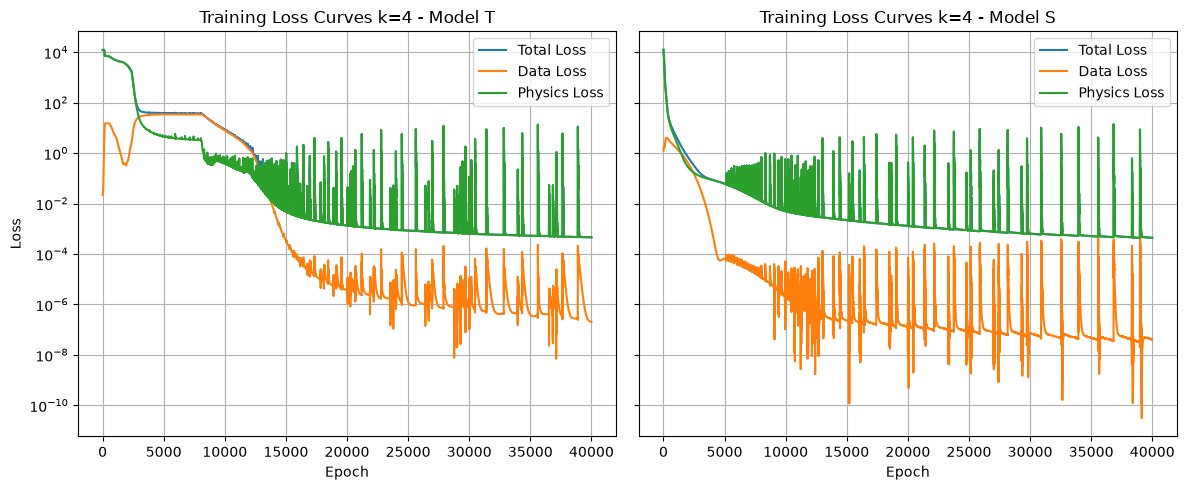

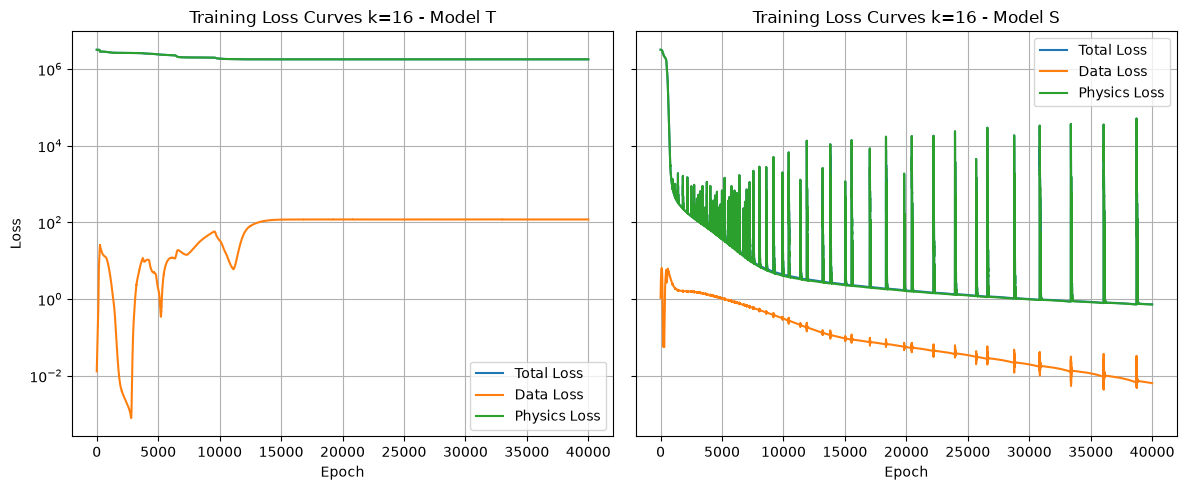

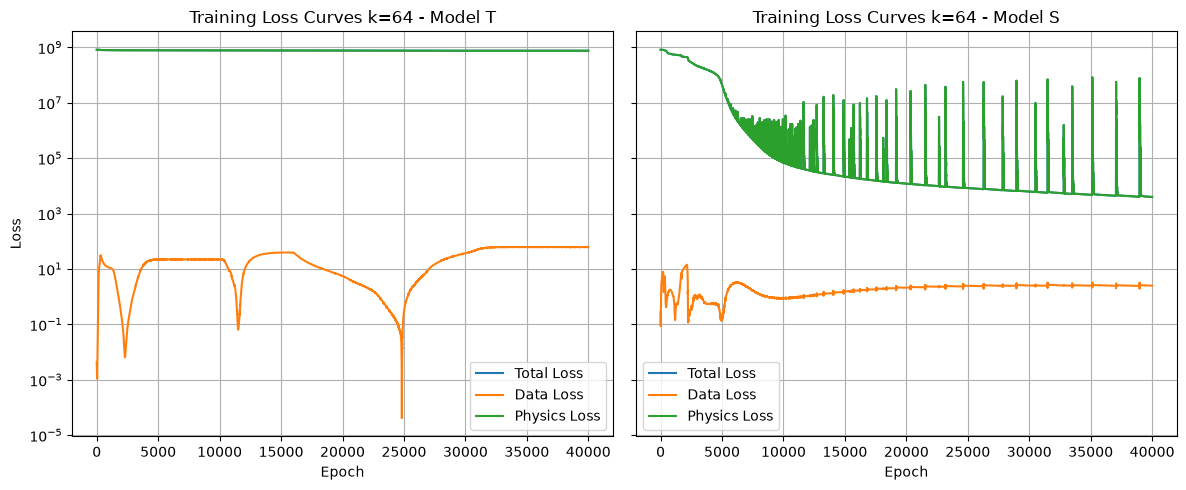

In [8]:
for i,k in enumerate(k_value):

    t_loss = losses["model_t"][i][0]
    t_data_loss = losses["model_t"][i][2]
    t_phys_loss = losses["model_t"][i][1]

    s_loss = losses["model_s"][i][0]
    s_data_loss = losses["model_s"][i][2]
    s_phys_loss = losses["model_s"][i][1]

    epochs = range(len(t_loss))

    fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    ax[0].plot(epochs, t_loss, label='Total Loss')
    ax[0].plot(epochs, t_data_loss, label='Data Loss')
    ax[0].plot(epochs, t_phys_loss, label='Physics Loss')

    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Loss')
    ax[0].set_title(f'Training Loss Curves k={k} - Model T')
    ax[0].set_yscale('log')
    ax[0].legend()
    ax[0].grid(True)

    ax[1].plot(epochs, s_loss, label='Total Loss')
    ax[1].plot(epochs, s_data_loss, label='Data Loss')
    ax[1].plot(epochs, s_phys_loss, label='Physics Loss')

    ax[1].set_xlabel('Epoch')
    ax[1].set_title(f'Training Loss Curves k={k} - Model S')
    ax[1].legend()
    ax[1].grid(True)

    plt.tight_layout()
    plt.show()



In [ ]:
# Frequency domain analysis

from torch.fft import fft, ifft, rfft, fftfreq

# what sort of fourier compoonents can be extracted from model. is siren periodic 